In [1]:
print("hello form pak")

hello form pak


In [3]:
import pandas as pd
import numpy as np 
import matplotlib as plt
import sklearn 

In [28]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [29]:
df = pd.read_csv("TSLA.csv")

In [ ]:
print("Initial Data Shape:", df.shape)
print(df)

Initial Data Shape: (2956, 7)
            Date         Open         High         Low        Close  \
0     2010-06-29     3.800000     5.000000    3.508000     4.778000   
1     2010-06-30     5.158000     6.084000    4.660000     4.766000   
2     2010-07-01     5.000000     5.184000    4.054000     4.392000   
3     2010-07-02     4.600000     4.620000    3.742000     3.840000   
4     2010-07-06     4.000000     4.000000    3.166000     3.222000   
...          ...          ...          ...         ...          ...   
2951  2022-03-18   874.489990   907.849976  867.390015   905.390015   
2952  2022-03-21   914.979980   942.849976  907.090027   921.159973   
2953  2022-03-22   930.000000   997.859985  921.750000   993.979980   
2954  2022-03-23   979.940002  1040.699951  976.400024   999.109985   
2955  2022-03-24  1009.729980  1024.489990  988.799988  1013.919983   

        Adj Close    Volume  
0        4.778000  93831500  
1        4.766000  85935500  
2        4.392000  41094000

In [35]:

print(df.iloc[5])

Date         2010-07-07
Open               3.28
High              3.326
Low               2.996
Close              3.16
Adj Close          3.16
Volume         34608500
Name: 5, dtype: object


In [36]:
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

In [37]:
df = df.fillna(df.mean(numeric_only=True))

In [38]:

print("After Cleaning:", df.shape)

After Cleaning: (2956, 7)


In [ ]:
# le = LabelEncoder()
# df["Target"] = le.fit_transform(df["Target"])

KeyError: 'Target'

In [41]:
# X = df.drop("Target", axis=1)
# y = df["Target"]
print(df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [42]:
df = df.fillna(df.mean(numeric_only=True))

# Drop unnecessary column
if "Date" in df.columns:
    df = df.drop("Date", axis=1)

# Create target
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
df = df.dropna()

# Split
X = df.drop("Target", axis=1)
y = df["Target"]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [44]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:

model = RandomForestClassifier()

In [46]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

In [47]:
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [48]:
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [49]:
best_model = grid.best_estimator_

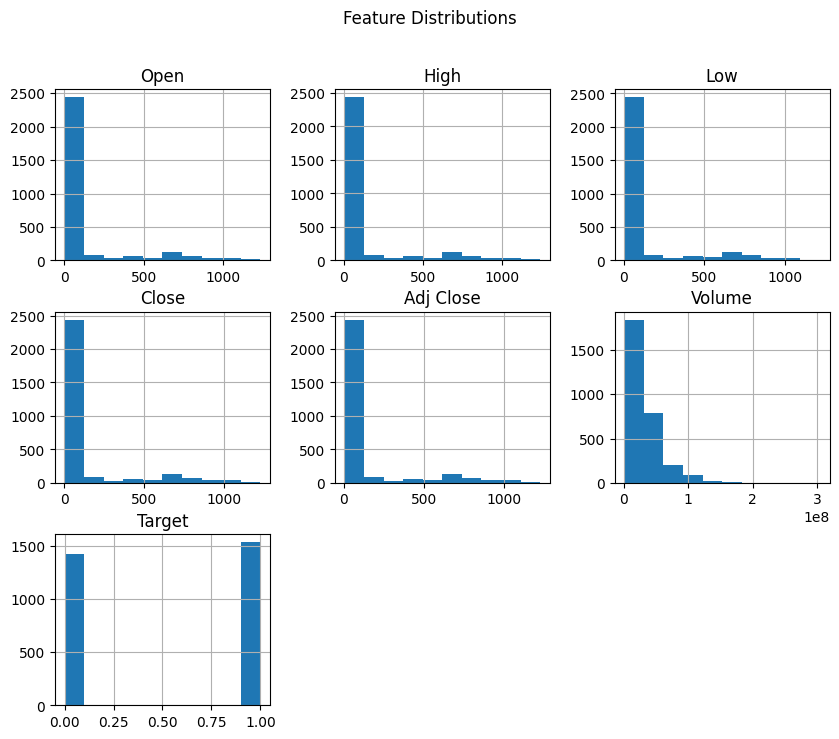

In [50]:
import matplotlib.pyplot as plt

# 1. Histogram (distribution of features)
df.hist(figsize=(10, 8))
plt.suptitle("Feature Distributions")
plt.show()

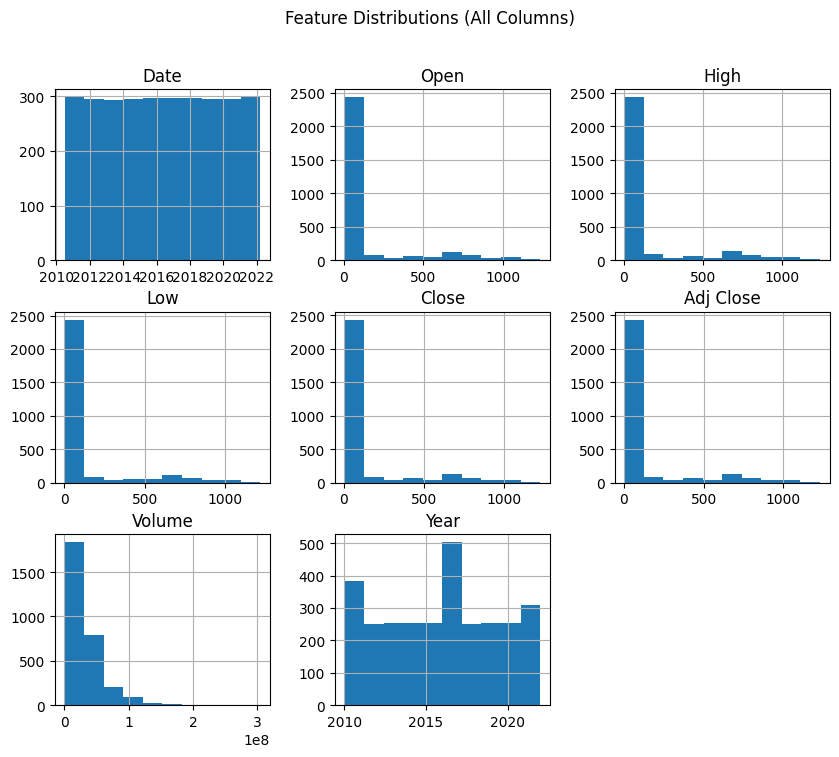

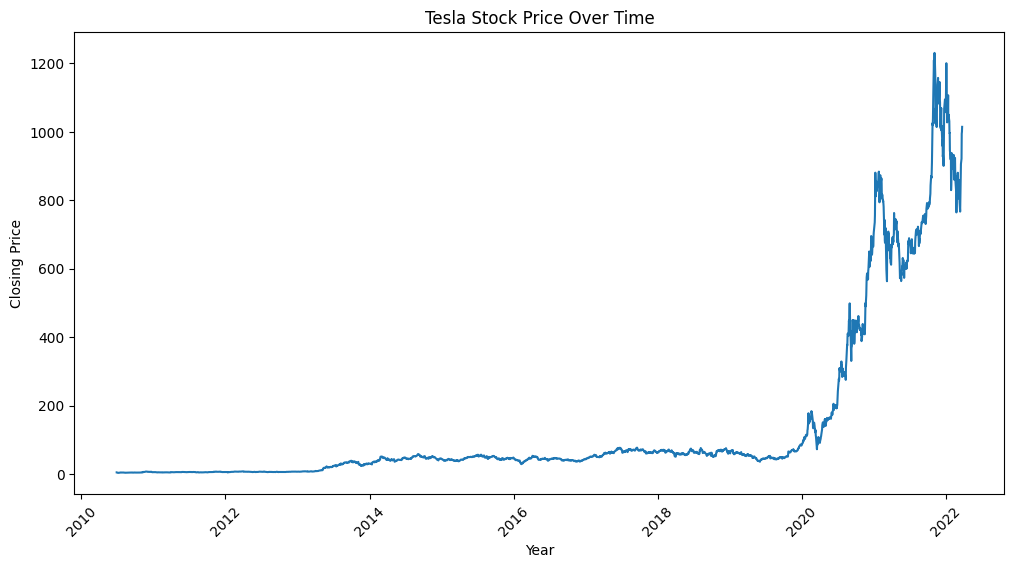

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("TSLA.csv")

# -----------------------------
# 1. Convert Date to datetime
# -----------------------------
df["Date"] = pd.to_datetime(df["Date"])

# Extract Year
df["Year"] = df["Date"].dt.year

# -----------------------------
# 2. Histogram (Feature Distribution)
# -----------------------------
df.hist(figsize=(10, 8))
plt.suptitle("Feature Distributions (All Columns)")
plt.show()

# -----------------------------
# 3. Year vs Price (IMPORTANT)
# -----------------------------
plt.figure(figsize=(12, 6))

# Plot closing price over time
plt.plot(df["Date"], df["Close"])

plt.title("Tesla Stock Price Over Time")
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)

plt.show()

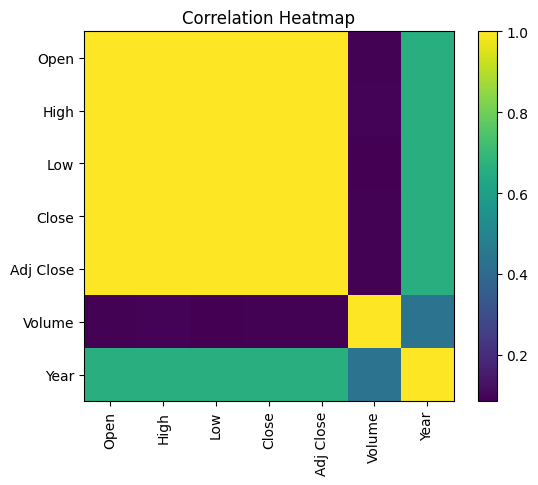

In [52]:
# le = LabelEncoder()
# df["Target"] = le.fit_transform(df["Target"])

# =========================
# HEATMAP
# =========================
corr = df.corr(numeric_only=True)

plt.figure()
plt.imshow(corr)

plt.colorbar()

# Labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

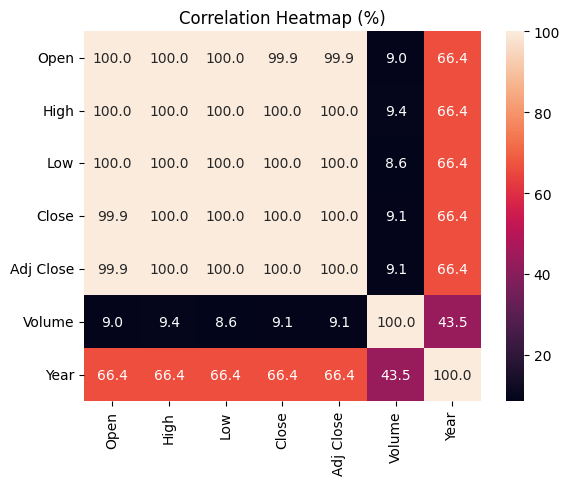

In [53]:
import seaborn as sns 
corr = df.corr(numeric_only=True)

# Convert to percentage
corr_percent = corr * 100

# =========================
# HEATMAP
# =========================
plt.figure()  
sns.heatmap(
    corr_percent,
    annot=True,        # show values
    fmt=".1f",         # 1 decimal
)

plt.title("Correlation Heatmap (%)")
plt.show()

In [54]:
y_pred = best_model.predict(X_test)

In [57]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.46621621621621623

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.38      0.41       292
           1       0.48      0.55      0.51       300

    accuracy                           0.47       592
   macro avg       0.46      0.47      0.46       592
weighted avg       0.46      0.47      0.46       592



In [59]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)   # 👈 REQUIRED

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [63]:
df = pd.read_csv("TSLA.csv")
print(df.head())

         Date   Open   High    Low  Close  Adj Close    Volume
0  2010-06-29  3.800  5.000  3.508  4.778      4.778  93831500
1  2010-06-30  5.158  6.084  4.660  4.766      4.766  85935500
2  2010-07-01  5.000  5.184  4.054  4.392      4.392  41094000
3  2010-07-02  4.600  4.620  3.742  3.840      3.840  25699000
4  2010-07-06  4.000  4.000  3.166  3.222      3.222  34334500


In [64]:
# last_data = df[["Open", "High", "Low", "Close", "Volume"]].iloc[-1].values.reshape(1, -1)

# next_day_price = model.predict(last_data)

# print("Next Day Predicted Price:", next_day_price[0])

print(X_train.columns)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [65]:
y_pred = model.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.4847972972972973


In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[135 157]
 [148 152]]


In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.46      0.47       292
           1       0.49      0.51      0.50       300

    accuracy                           0.48       592
   macro avg       0.48      0.48      0.48       592
weighted avg       0.48      0.48      0.48       592



In [70]:
import numpy as np

In [72]:
last_data = X_test[-1].reshape(1, -1)

prediction = model.predict(last_data)

print("Predicted class:", prediction[0])

Predicted class: 0


In [73]:
import pandas as pd

X_test_df = pd.DataFrame(X_test)

last_data = X_test_df.iloc[-1].values.reshape(1, -1)

prediction = model.predict(last_data)

print("Predicted class:", prediction[0])

Predicted class: 0


In [74]:
last_data = X_test[-1].reshape(1, -1)

prediction = model.predict(last_data)

print("Predicted class:", prediction[0])

Predicted class: 0


In [79]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# 1. Load the data
df = pd.read_csv('TSLA.csv')

# --- THE FIX IS HERE ---
# Convert 'Date' from string to actual datetime objects
df['Date'] = pd.to_datetime(df['Date'])
# -----------------------

# 2. Now you can use .dt without the AttributeError
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['UnixTime'] = df['Date'].astype('int64') // 10**9

# Now proceed with your training...

In [82]:
print(df)

            Date         Open         High         Low        Close  \
0     2010-06-29     3.800000     5.000000    3.508000     4.778000   
1     2010-06-30     5.158000     6.084000    4.660000     4.766000   
2     2010-07-01     5.000000     5.184000    4.054000     4.392000   
3     2010-07-02     4.600000     4.620000    3.742000     3.840000   
4     2010-07-06     4.000000     4.000000    3.166000     3.222000   
...          ...          ...          ...         ...          ...   
2951  2022-03-18   874.489990   907.849976  867.390015   905.390015   
2952  2022-03-21   914.979980   942.849976  907.090027   921.159973   
2953  2022-03-22   930.000000   997.859985  921.750000   993.979980   
2954  2022-03-23   979.940002  1040.699951  976.400024   999.109985   
2955  2022-03-24  1009.729980  1024.489990  988.799988  1013.919983   

        Adj Close    Volume  
0        4.778000  93831500  
1        4.766000  85935500  
2        4.392000  41094000  
3        3.840000  25699000

In [83]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# 1. Load the data
df = pd.read_csv('TSLA.csv')

# 2. Convert Date to Datetime (Fixes the AttributeError)
df['Date'] = pd.to_datetime(df['Date'])

# 3. Create the features (Make sure these are NOT commented out!)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['UnixTime'] = df['Date'].astype('int64') // 10**9

# 4. Now X will find the columns (Fixes the KeyError)
X = df[['Year', 'Month', 'Day', 'UnixTime']]
y = df['Close']

# 5. Simple Train/Test Split
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# 6. Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


c:\Users\AB TRADERS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


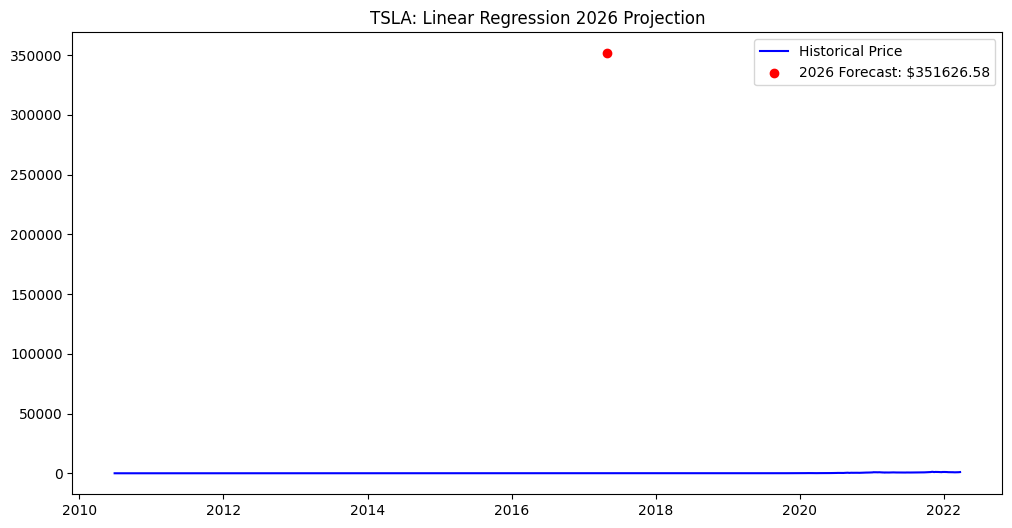

Linear Regression Forecast for May 2026: $351626.58


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Load and Prepare Data
df = pd.read_csv('TSLA.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# 2. Feature Engineering
# We use UnixTime (seconds since 1970) as a continuous number for the X-axis
df['UnixTime'] = df['Date'].astype('int64') // 10**9
X = df[['UnixTime']]
y = df['Close']

# 3. Train/Test Split (80% Train, 20% Test)
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# 4. Training the Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 5. Testing and Future Prediction
# Create a timestamp for May 1st, 2026
future_date = pd.to_datetime('2017-05-01')
future_unix = np.array([[future_date.timestamp()]])
future_value = lr_model.predict(future_unix)[0]

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], y, label='Historical Price', color='blue')
plt.scatter(future_date, future_value, color='red', label=f'2026 Forecast: ${future_value:.2f}')
plt.title('TSLA: Linear Regression 2026 Projection')
plt.legend()
plt.show()

print(f"Linear Regression Forecast for May 2026: ${future_value:.2f}")

In [87]:
print("hello")

hello


In [89]:
pf=pd.read_csv('USD_PKR Historical Data (1).csv')

In [90]:
print(pf.head(5))

         Date    Price     Open     High      Low Vol. Change %
0  01/02/2024  278.981  278.981  278.981  278.981  NaN    0.00%
1  01/01/2024  278.981  278.729  279.132  278.729  NaN    0.09%
2  12/31/2023  278.729  278.729  278.729  278.729  NaN    0.18%
3  12/29/2023  278.218  282.000  282.000  278.218  NaN   -1.38%
4  12/28/2023  282.100  281.500  282.750  277.980  NaN    0.10%


In [91]:

pf = pf.drop(columns=["High", "Low", "Volume", "Change"], errors="ignore")

In [92]:
print(pf.head(5))

         Date    Price     Open Vol. Change %
0  01/02/2024  278.981  278.981  NaN    0.00%
1  01/01/2024  278.981  278.729  NaN    0.09%
2  12/31/2023  278.729  278.729  NaN    0.18%
3  12/29/2023  278.218  282.000  NaN   -1.38%
4  12/28/2023  282.100  281.500  NaN    0.10%


In [93]:

pf = pf.drop(columns=[ "Vol.", "Change %"], errors="ignore")

In [94]:
print(pf.head(5))


         Date    Price     Open
0  01/02/2024  278.981  278.981
1  01/01/2024  278.981  278.729
2  12/31/2023  278.729  278.729
3  12/29/2023  278.218  282.000
4  12/28/2023  282.100  281.500


In [95]:
##date after 2016

# Convert Date column to datetime
pf["Date"] = pd.to_datetime(pf["Date"])

# Filter data from 2016-01-29 onwards
pf = pf[pf["Date"] >= "2016-01-29"]

# Sort by date (important for time series)
pf = pf.sort_values("Date")

# Optional: set Date as index
pf = pf.set_index("Date")

# Show first 5 rows
print(pf.head(5))

              Price    Open
Date                       
2016-01-29  104.850  104.75
2016-01-30  104.850  104.70
2016-02-01  104.950  104.89
2016-02-02  104.920  104.90
2016-02-03  104.855  104.90


In [97]:
print(pf)

              Price     Open
Date                        
2016-01-29  104.850  104.750
2016-01-30  104.850  104.700
2016-02-01  104.950  104.890
2016-02-02  104.920  104.900
2016-02-03  104.855  104.900
...             ...      ...
2023-12-28  282.100  281.500
2023-12-29  278.218  282.000
2023-12-31  278.729  278.729
2024-01-01  278.981  278.729
2024-01-02  278.981  278.981

[2370 rows x 2 columns]


In [115]:
# Rename Price column
pf = pf.rename(columns={"Price": "pkr_to_oneDollar"})
pf = pf.rename(columns={"Open": "Open_Dollar"})
pf=pf.drop(columns="Open_Dollar" ,errors="ignore")

# Show result
print(pf.head(5))

        Date  pkr_to_oneDollar
0 2016-01-29           104.850
1 2016-01-30           104.850
2 2016-02-01           104.950
3 2016-02-02           104.920
4 2016-02-03           104.855


In [98]:
gf=pd.read_csv("gold_prices_10y.csv")

In [99]:
print(gf.head(5))

         Date       Close        High         Low        Open    Volume  \
0  2016-01-29  106.949997  107.000000  106.260002  106.610001   8098700   
1  2016-02-01  108.050003  108.150002  107.529999  107.540001  10471800   
2  2016-02-02  108.089996  108.180000  107.349998  107.919998   6656000   
3  2016-02-03  109.250000  109.580002  107.900002  107.910004  15785200   
4  2016-02-04  110.570000  110.699997  109.919998  110.449997  13213700   

    Adj Close  Daily_Return  MA_20  MA_50  MA_200  Volatility_20  Year  Month  \
0  106.949997           NaN    NaN    NaN     NaN            NaN  2016      1   
1  108.050003      1.028524    NaN    NaN     NaN            NaN  2016      2   
2  108.089996      0.037014    NaN    NaN     NaN            NaN  2016      2   
3  109.250000      1.073183    NaN    NaN     NaN            NaN  2016      2   
4  110.570000      1.208238    NaN    NaN     NaN            NaN  2016      2   

   Day_of_Week  Quarter  
0            4        1  
1         

In [101]:
gf=gf.drop(columns=["High","Low","Close","Volume"], errors="ignore")

In [102]:
print(gf.head(5))

         Date        Open   Adj Close  Daily_Return  MA_20  MA_50  MA_200  \
0  2016-01-29  106.610001  106.949997           NaN    NaN    NaN     NaN   
1  2016-02-01  107.540001  108.050003      1.028524    NaN    NaN     NaN   
2  2016-02-02  107.919998  108.089996      0.037014    NaN    NaN     NaN   
3  2016-02-03  107.910004  109.250000      1.073183    NaN    NaN     NaN   
4  2016-02-04  110.449997  110.570000      1.208238    NaN    NaN     NaN   

   Volatility_20  Year  Month  Day_of_Week  Quarter  
0            NaN  2016      1            4        1  
1            NaN  2016      2            0        1  
2            NaN  2016      2            1        1  
3            NaN  2016      2            2        1  
4            NaN  2016      2            3        1  


In [105]:
gf=gf.drop(columns=["Adj Close","Daily_Return","MA_20","MA_50","MA_200","Volatility_20","Year","Month","Day_of_Week","Quarter"],errors="ignore")

In [106]:
print(gf.head(5))

         Date        Open
0  2016-01-29  106.610001
1  2016-02-01  107.540001
2  2016-02-02  107.919998
3  2016-02-03  107.910004
4  2016-02-04  110.449997


In [ ]:

gf = gf.rename(columns={"Open": "Gol_Price"})

In [118]:
gf=gf.drop(columns="index",errors="ignore")

In [119]:
print(gf.head(5))

        Date   Gol_Price
0 2016-01-29  106.610001
1 2016-02-01  107.540001
2 2016-02-02  107.919998
3 2016-02-03  107.910004
4 2016-02-04  110.449997


In [120]:
print(pf.columns)
print(gf.columns)

Index(['Date', 'pkr_to_oneDollar'], dtype='str')
Index(['Date', 'Gol_Price'], dtype='str')


In [121]:
pf.columns = pf.columns.str.strip()
gf.columns = gf.columns.str.strip()

In [122]:
pf = pf.reset_index()
gf = gf.reset_index()

In [123]:
# rename if needed (adjust based on your output)
if "date" in pf.columns:
    pf.rename(columns={"date": "Date"}, inplace=True)

if "date" in gf.columns:
    gf.rename(columns={"date": "Date"}, inplace=True)

In [124]:
import pandas as pd

# Ensure Date column is in datetime format
pf["Date"] = pd.to_datetime(pf["Date"])
gf["Date"] = pd.to_datetime(gf["Date"])

# If Date is index (from previous step), reset it
if "Date" not in pf.columns:
    pf = pf.reset_index()

if "Date" not in gf.columns:
    gf = gf.reset_index()

# Merge both datasets on Date
merged_df = pd.merge(pf, gf, on="Date", how="inner")

# Sort by Date (important for time series)
merged_df = merged_df.sort_values("Date")

# Show results
print(merged_df.head(5))

   index_x       Date  pkr_to_oneDollar  index_y   Gol_Price
0        0 2016-01-29           104.850        0  106.610001
1        2 2016-02-01           104.950        1  107.540001
2        3 2016-02-02           104.920        2  107.919998
3        4 2016-02-03           104.855        3  107.910004
4        5 2016-02-04           104.300        4  110.449997


In [125]:
merged_df=merged_df.drop(columns=["index_x","index_y"],errors="ignore")

In [126]:
print(merged_df)

           Date  pkr_to_oneDollar   Gol_Price
0    2016-01-29           104.850  106.610001
1    2016-02-01           104.950  107.540001
2    2016-02-02           104.920  107.919998
3    2016-02-03           104.855  107.910004
4    2016-02-04           104.300  110.449997
...         ...               ...         ...
1988 2023-12-26           282.000  190.970001
1989 2023-12-27           281.820  191.770004
1990 2023-12-28           282.100  192.339996
1991 2023-12-29           278.218  190.990005
1992 2024-01-02           278.981  191.440002

[1993 rows x 3 columns]


In [127]:
merged_df=merged_df.rename(columns={"Gol_Price" :"Gold_Price_In_Dolars"})

In [130]:
print(merged_df.head(2))

        Date  pkr_to_oneDollar  Gold_Price_In_Dolars
0 2016-01-29            104.85            106.610001
1 2016-02-01            104.95            107.540001


In [153]:
import pandas as pd

# Ensure datetime
merged_df["Date"] = pd.to_datetime(merged_df["Date"])

# Convert to Month Start (1st day of each month)
merged_df["Date"] = merged_df["Date"].dt.to_period("M").dt.to_timestamp()

# Remove duplicates (keep one row per month)
monthly_df = merged_df.drop_duplicates(subset="Date")

# Sort just in case
monthly_df = monthly_df.sort_values("Date")

# Show result
print(monthly_df.head(2))

        Date  pkr_to_oneDollar  Gold_Price_In_Dolars
0 2016-01-01            104.85            106.610001
1 2016-02-01            104.95            107.540001


In [154]:
print(monthly_df)

           Date  pkr_to_oneDollar  Gold_Price_In_Dolars
0    2016-01-01           104.850            106.610001
1    2016-02-01           104.950            107.540001
21   2016-03-01           104.850            118.739998
43   2016-04-01           104.760            116.080002
64   2016-05-01           104.790            123.779999
...         ...               ...                   ...
1909 2023-09-01           305.500            180.800003
1929 2023-10-01           288.300            170.229996
1951 2023-11-01           280.750            183.910004
1972 2023-12-01           284.960            188.809998
1992 2024-01-01           278.981            191.440002

[97 rows x 3 columns]


In [155]:
# Ensure datetime
monthly_df["Date"] = pd.to_datetime(monthly_df["Date"])

# Convert to Year-Month format
monthly_df["Date"] = monthly_df["Date"].dt.strftime("%Y-%m")

# Show result
print(monthly_df.head(5))

       Date  pkr_to_oneDollar  Gold_Price_In_Dolars
0   2016-01            104.85            106.610001
1   2016-02            104.95            107.540001
21  2016-03            104.85            118.739998
43  2016-04            104.76            116.080002
64  2016-05            104.79            123.779999


In [156]:
print(monthly_df)

         Date  pkr_to_oneDollar  Gold_Price_In_Dolars
0     2016-01           104.850            106.610001
1     2016-02           104.950            107.540001
21    2016-03           104.850            118.739998
43    2016-04           104.760            116.080002
64    2016-05           104.790            123.779999
...       ...               ...                   ...
1909  2023-09           305.500            180.800003
1929  2023-10           288.300            170.229996
1951  2023-11           280.750            183.910004
1972  2023-12           284.960            188.809998
1992  2024-01           278.981            191.440002

[97 rows x 3 columns]


In [131]:
petf=pd.read_csv('petrol_prices_pakistan_2010_2025.csv')

In [132]:
print(petf.head(5))

      Date  Petrol Price (PKR per litre)
0  2010-01                         66.36
1  2010-02                         66.36
2  2010-03                         69.03
3  2010-04                         71.21
4  2010-05                         72.96


In [137]:
petf["Date"] = pd.to_datetime(petf["Date"])
petf = petf[petf["Date"] >= "2016-01-01"]
petf = petf.sort_values("Date")

In [138]:
print(petf.head(5))

         Date  Petrol Price (PKR per litre)
72 2016-01-01                         71.50
73 2016-02-01                         71.50
74 2016-03-01                         70.29
75 2016-04-01                         72.00
76 2016-05-01                         74.96


In [158]:
# Ensure Date is datetime
petf["Date"] = pd.to_datetime(petf["Date"])

# Convert to Year-Month format
petf["Date"] = petf["Date"].dt.strftime("%Y-%m")

# Show result
print(petf)

        Date  Petrol Price (PKR per litre)
72   2016-01                         71.50
73   2016-02                         71.50
74   2016-03                         70.29
75   2016-04                         72.00
76   2016-05                         74.96
..       ...                           ...
180  2025-01                        281.30
181  2025-02                        284.50
182  2025-03                        287.20
183  2025-04                        289.10
184  2025-05                        292.00

[113 rows x 2 columns]


In [161]:
import pandas as pd

# Ensure Date is in same format (Year-Month)
monthly_df["Date"] = pd.to_datetime(monthly_df["Date"]).dt.strftime("%Y-%m")
petf["Date"] = pd.to_datetime(petf["Date"]).dt.strftime("%Y-%m")

# Merge on Date
merged_final = pd.merge(monthly_df, petf, on="Date", how="inner")

# Sort by Date
merged_final = merged_final.sort_values("Date")

# Show result
print(merged_final)

       Date  pkr_to_oneDollar  Gold_Price_In_Dolars  \
0   2016-01           104.850            106.610001   
1   2016-02           104.950            107.540001   
2   2016-03           104.850            118.739998   
3   2016-04           104.760            116.080002   
4   2016-05           104.790            123.779999   
..      ...               ...                   ...   
92  2023-09           305.500            180.800003   
93  2023-10           288.300            170.229996   
94  2023-11           280.750            183.910004   
95  2023-12           284.960            188.809998   
96  2024-01           278.981            191.440002   

    Petrol Price (PKR per litre)  
0                          71.50  
1                          71.50  
2                          70.29  
3                          72.00  
4                          74.96  
..                           ...  
92                        283.38  
93                        283.38  
94                      

In [166]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

In [167]:
print(merged_final.head(5))

      Date  pkr_to_oneDollar  Gold_Price_In_Dolars  \
0  2016-01            104.85            106.610001   
1  2016-02            104.95            107.540001   
2  2016-03            104.85            118.739998   
3  2016-04            104.76            116.080002   
4  2016-05            104.79            123.779999   

   Petrol Price (PKR per litre)  
0                         71.50  
1                         71.50  
2                         70.29  
3                         72.00  
4                         74.96  


In [177]:
merged_final["Date"] = pd.to_datetime(merged_final["Date"])

merged_final["Year"] = merged_final["Date"].dt.year
merged_final["Month"] = merged_final["Date"].dt.month

In [179]:
print(merged_final.drop(columns="Date",errors="ignore"))

    pkr_to_oneDollar  Gold_Price_In_Dolars  Petrol Price (PKR per litre)  \
0            104.850            106.610001                         71.50   
1            104.950            107.540001                         71.50   
2            104.850            118.739998                         70.29   
3            104.760            116.080002                         72.00   
4            104.790            123.779999                         74.96   
..               ...                   ...                           ...   
92           305.500            180.800003                        283.38   
93           288.300            170.229996                        283.38   
94           280.750            183.910004                        281.38   
95           284.960            188.809998                        267.34   
96           278.981            191.440002                        259.34   

    Year  Month  
0   2016      1  
1   2016      2  
2   2016      3  
3   2016      4

In [180]:
merged_final = merged_final.rename(columns={
    "Petrol Price (PKR per litre)": "Petrol_Price"
})

In [191]:
print(merged_final.head(5))

         Date  pkr_to_oneDollar  Gold_Price_In_Dolars  Petrol_Price  Year  \
9  2016-10-01           104.505            125.320000         81.33  2016   
10 2016-11-01           104.730            122.800003         82.10  2016   
11 2016-12-01           104.800            111.110001         83.25  2016   
12 2017-01-01           104.795            109.620003         85.23  2017   
13 2017-02-01           104.750            114.660004         87.92  2017   

    Month    lag_1    lag_2    lag_3  rolling_mean_3  diff_1  
9      10  104.605  104.700  104.750      104.603333  -0.100  
10     11  104.505  104.605  104.700      104.613333   0.225  
11     12  104.730  104.505  104.605      104.678333   0.070  
12      1  104.800  104.730  104.505      104.775000  -0.005  
13      2  104.795  104.800  104.730      104.781667  -0.045  


In [182]:
X = merged_final.iloc[:, [2, 3, 4, 5]]   # Gold, Petrol, Year, Month
y = merged_final.iloc[:, 1]              # pkr_to_oneDollar

In [183]:
split = int(len(merged_final) * 0.8)

In [184]:
X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [185]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [186]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

MAE: 78.08337500000005


In [190]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# -----------------------------
# 1. PREPROCESSING
# -----------------------------
merged_final["Date"] = pd.to_datetime(merged_final["Date"])
merged_final = merged_final.sort_values("Date")

merged_final["Year"] = merged_final["Date"].dt.year
merged_final["Month"] = merged_final["Date"].dt.month

merged_final = merged_final.rename(columns={
    "Petrol Price (PKR per litre)": "Petrol_Price"
})

# -----------------------------
# 2. STRONGER FEATURE ENGINEERING
# -----------------------------

# Lag features (ONLY past real values)
merged_final["lag_1"] = merged_final["pkr_to_oneDollar"].shift(1)
merged_final["lag_2"] = merged_final["pkr_to_oneDollar"].shift(2)
merged_final["lag_3"] = merged_final["pkr_to_oneDollar"].shift(3)

# Trend features
merged_final["rolling_mean_3"] = merged_final["pkr_to_oneDollar"].rolling(3).mean()

# Remove NaN
merged_final = merged_final.dropna()

# -----------------------------
# 3. FEATURES & TARGET
# -----------------------------
X = merged_final[[
    "Gold_Price_In_Dolars",
    "Petrol_Price",
    "Year",
    "Month",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3"
]]

y = merged_final["pkr_to_oneDollar"]

# -----------------------------
# 4. TRAIN / TEST SPLIT (TIME ORDER)
# -----------------------------
split = int(len(merged_final) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# -----------------------------
# 5. MODEL (MORE STABLE)
# -----------------------------
model = RandomForestRegressor(
    n_estimators=500,   # more trees = better stability
    max_depth=10,       # prevents overfitting
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# 6. EVALUATION
# -----------------------------
pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, pred))

# -----------------------------
# 7. FUTURE PREDICTION (FIXED LOGIC)
# -----------------------------
target_year = int(input("Enter year: "))

history = merged_final.copy()
last = history.iloc[-1]

predictions = []

lag_1 = last["pkr_to_oneDollar"]
lag_2 = last["lag_1"]
lag_3 = last["lag_2"]

rolling_vals = list(history["pkr_to_oneDollar"].tail(3))

for month in range(1, 13):

    rolling_mean = np.mean(rolling_vals[-3:])

    input_row = np.array([[
        last["Gold_Price_In_Dolars"],
        last["Petrol_Price"],
        target_year,
        month,
        lag_1,
        lag_2,
        lag_3,
        rolling_mean
    ]])

    pred_value = model.predict(input_row)[0]

    predictions.append((target_year, month, pred_value))

    # update lags
    lag_3 = lag_2
    lag_2 = lag_1
    lag_1 = pred_value

    rolling_vals.append(pred_value)

# -----------------------------
# 8. OUTPUT
# -----------------------------
result_df = pd.DataFrame(predictions, columns=["Year", "Month", "Predicted_PKR_USD"])

print("\n📊 Final Forecast:")
print(result_df)

MAE: 63.97334555555571


c:\Users\AB TRADERS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\AB TRADERS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\AB TRADERS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\AB TRADERS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\AB TRADERS\AppData\Local\Programs\Python\Python313\


📊 Final Forecast:
    Year  Month  Predicted_PKR_USD
0   2025      1           198.7356
1   2025      2           198.7356
2   2025      3           198.7381
3   2025      4           198.7647
4   2025      5           198.8093
5   2025      6           199.5307
6   2025      7           200.1041
7   2025      8           199.9914
8   2025      9           199.9914
9   2025     10           199.9914
10  2025     11           199.9914
11  2025     12           199.9914


In [187]:

last_row = merged_final.iloc[-1]

future_gold   = last_row["Gold_Price_In_Dolars"]   # you can change
future_petrol = last_row["Petrol_Price"]           # you can change

# Next month calculation
future_year  = last_row["Year"]
future_month = last_row["Month"] + 1

if future_month > 12:
    future_month = 1
    future_year += 1

# Create input
future_input = np.array([[future_gold, future_petrol, future_year, future_month]])

future_pred = model.predict(future_input)

print("Next Month Prediction (PKR/USD):", future_pred[0])

Next Month Prediction (PKR/USD): 180.17520000000005


c:\Users\AB TRADERS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [188]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# -----------------------------
# 1. LOAD DATA
# -----------------------------
# merged_final = pd.read_csv("your_file.csv")

# -----------------------------
# 2. PREPROCESSING
# -----------------------------
merged_final["Date"] = pd.to_datetime(merged_final["Date"])
merged_final = merged_final.sort_values("Date")

# Time features
merged_final["Year"] = merged_final["Date"].dt.year
merged_final["Month"] = merged_final["Date"].dt.month

# Rename column (fix space issue)
merged_final = merged_final.rename(columns={
    "Petrol Price (PKR per litre)": "Petrol_Price"
})

# -----------------------------
# 3. PATTERN FEATURES (VERY IMPORTANT)
# -----------------------------
merged_final["lag_1"] = merged_final["pkr_to_oneDollar"].shift(1)
merged_final["lag_2"] = merged_final["pkr_to_oneDollar"].shift(2)
merged_final["lag_3"] = merged_final["pkr_to_oneDollar"].shift(3)

merged_final["rolling_mean_3"] = merged_final["pkr_to_oneDollar"].rolling(3).mean()
merged_final["diff_1"] = merged_final["pkr_to_oneDollar"].diff(1)

# Remove NaN created by shifts
merged_final = merged_final.dropna()

# -----------------------------
# 4. FEATURES & TARGET
# -----------------------------
X = merged_final[[
    "Gold_Price_In_Dolars",
    "Petrol_Price",
    "Year",
    "Month",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "diff_1"
]]

y = merged_final["pkr_to_oneDollar"]

# -----------------------------
# 5. TRAIN / TEST SPLIT (TIME ORDER)
# -----------------------------
split = int(len(merged_final) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

# -----------------------------
# 6. MODEL TRAINING
# -----------------------------
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# 7. PREDICTION & EVALUATION
# -----------------------------
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

# -----------------------------
# 8. FUTURE PREDICTION
# -----------------------------
last = merged_final.iloc[-1]

future_year = last["Year"]
future_month = last["Month"] + 1

if future_month > 12:
    future_month = 1
    future_year += 1

future_input = np.array([[
    last["Gold_Price_In_Dolars"],
    last["Petrol_Price"],
    future_year,
    future_month,
    last["pkr_to_oneDollar"],   # lag_1
    last["lag_1"],              # lag_2
    last["lag_2"],              # lag_3
    last["rolling_mean_3"],
    last["diff_1"]
]])

future_prediction = model.predict(future_input)

print("Next Month Predicted PKR/USD:", future_prediction[0])

MAE: 71.11932368421013
Next Month Predicted PKR/USD: 188.85650000000044


c:\Users\AB TRADERS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [189]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# -----------------------------
# 1. PREPROCESSING
# -----------------------------
merged_final["Date"] = pd.to_datetime(merged_final["Date"])
merged_final = merged_final.sort_values("Date")

merged_final["Year"] = merged_final["Date"].dt.year
merged_final["Month"] = merged_final["Date"].dt.month

merged_final = merged_final.rename(columns={
    "Petrol Price (PKR per litre)": "Petrol_Price"
})

# -----------------------------
# 2. PATTERN FEATURES
# -----------------------------
merged_final["lag_1"] = merged_final["pkr_to_oneDollar"].shift(1)
merged_final["lag_2"] = merged_final["pkr_to_oneDollar"].shift(2)
merged_final["lag_3"] = merged_final["pkr_to_oneDollar"].shift(3)

merged_final["rolling_mean_3"] = merged_final["pkr_to_oneDollar"].rolling(3).mean()
merged_final["diff_1"] = merged_final["pkr_to_oneDollar"].diff(1)

merged_final = merged_final.dropna()

# -----------------------------
# 3. FEATURES & TARGET
# -----------------------------
X = merged_final[[
    "Gold_Price_In_Dolars",
    "Petrol_Price",
    "Year",
    "Month",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "diff_1"
]]

y = merged_final["pkr_to_oneDollar"]

# -----------------------------
# 4. TRAIN MODEL
# -----------------------------
split = int(len(merged_final) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# -----------------------------
# 5. USER INPUT YEAR
# -----------------------------
target_year = int(input("Enter year for prediction (e.g., 2025): "))

# -----------------------------
# 6. START FROM LAST AVAILABLE DATA
# -----------------------------
history = merged_final.copy()
last_row = history.iloc[-1]

predictions = []

current_gold = last_row["Gold_Price_In_Dolars"]
current_petrol = last_row["Petrol_Price"]

lag_1 = last_row["pkr_to_oneDollar"]
lag_2 = last_row["lag_1"]
lag_3 = last_row["lag_2"]

rolling_values = list(history["pkr_to_oneDollar"].tail(3))

# -----------------------------
# 7. GENERATE FUTURE MONTHS
# -----------------------------
for month in range(1, 13):

    # rolling mean & diff
    rolling_mean_3 = np.mean(rolling_values[-3:])
    diff_1 = rolling_values[-1] - rolling_values[-2]

    input_data = np.array([[
        current_gold,
        current_petrol,
        target_year,
        month,
        lag_1,
        lag_2,
        lag_3,
        rolling_mean_3,
        diff_1
    ]])

    pred = model.predict(input_data)[0]
    predictions.append((target_year, month, pred))

    # update lags (recursive forecasting)
    lag_3 = lag_2
    lag_2 = lag_1
    lag_1 = pred

    rolling_values.append(pred)

# -----------------------------
# 8. OUTPUT RESULTS
# -----------------------------
result_df = pd.DataFrame(predictions, columns=["Year", "Month", "Predicted_PKR_USD"])

print("\n📊 Future Forecast:")
print(result_df)

c:\Users\AB TRADERS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\AB TRADERS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\AB TRADERS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\AB TRADERS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\AB TRADERS\AppData\Local\Programs\Python\Python313\


📊 Future Forecast:
    Year  Month  Predicted_PKR_USD
0   2026      1          189.66800
1   2026      2          189.66665
2   2026      3          189.67780
3   2026      4          189.80380
4   2026      5          189.88205
5   2026      6          190.53720
6   2026      7          190.46640
7   2026      8          190.29430
8   2026      9          190.29430
9   2026     10          190.29430
10  2026     11          190.29430
11  2026     12          190.29430


In [193]:
merged_final.to_csv("cleaned_dataset.csv", index=False)

In [196]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Load the dataset
df = pd.read_csv('cleaned_dataset.csv')

# 2. Prepare the Features (X) and Targets (y)
# We use 'Year' to predict the other three values
X = df[['Year']].values
targets = {
    'USD/PKR': df['pkr_to_oneDollar'].values,
    'Gold (USD)': df['Gold_Price_In_Dolars'].values,
    'Petrol (PKR)': df['Petrol_Price'].values
}

# 3. Train a model for each target
models = {}
for name, y in targets.items():
    model = LinearRegression()
    model.fit(X, y)
    models[name] = model

# 4. Define the Prediction Function
def predict_prices(target_year):
    """
    Predicts prices for a specific year based on historical trends.
    """
    year_input = np.array([[target_year]])
    predictions = {}
    
    print(f"--- Predictions for the Year {target_year} ---")
    for name, model in models.items():
        price = model.predict(year_input)[0]
        predictions[name] = round(price, 2)
        print(f"{name}: {predictions[name]}")
    
    return predictions

# --- USER INPUT SECTION ---
# You can change this year to get different results
user_year = 2027
results = predict_prices(user_year)

--- Predictions for the Year 2027 ---
USD/PKR: 337.26
Gold (USD): 226.27
Petrol (PKR): 323.14


In [202]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Load the dataset
df = pd.read_csv('cleaned_dataset.csv')

# 2. Prepare the Features (X) and Targets (y)
# 'Year' remains our independent variable to find the trend
X = df[['Year']].values
targets = {
    'USD/PKR': df['pkr_to_oneDollar'].values,
    'Petrol (PKR)': df['Petrol_Price'].values
}

# 3. Train a model for each remaining target
# This calculates the mathematical relationship between the Year and the Price
models = {}
for name, y in targets.items():
    model = LinearRegression()
    model.fit(X, y)
    models[name] = model

# 4. Define the Prediction Function
def predict_prices(target_year):
    """
    Predicts USD and Petrol prices for a specific year based on historical data.
    """
    year_input = np.array([[target_year]])
    predictions = {}
    
    print(f"--- Economic Predictions for {target_year} ---")
    for name, model in models.items():
        # The model uses the learned slope to project the price
        price = model.predict(year_input)[0]
        predictions[name] = round(price, 2)
        print(f"{name}: {predictions[name]}")
    
    return predictions

# --- EXECUTION ---
# Input the year you want to forecast
user_year = 2035

results = predict_prices(user_year)

--- Economic Predictions for 2035 ---
USD/PKR: 528.87
Petrol (PKR): 531.5


In [203]:
pI=pd.read_csv('pakistan_inflation_data.csv')

In [204]:
print(pI.head(5))

       Date  Inflation_YoY  Oil_Price_USD_Barrel  Exchange_Rate_PKR_USD  \
0  Jul-2025            4.1                 64.01             282.944662   
1  Jun-2025            3.2                 65.33             283.728591   
2  May-2025            3.5                 59.91             282.013781   
3  Apr-2025            0.3                 62.01             280.996515   
4  Mar-2025            0.7                 67.07             280.193120   

   Interest_Rate  Money_Supply_M2_Billion  
0          11.00              41207.67951  
1          11.66              41785.62623  
2          12.24              39464.80716  
3          12.77              38757.42795  
4          12.39              38716.70135  


In [209]:
import pandas as pd

# Convert "Jul-2025" format into datetime
pI["date"] = pd.to_datetime(pI["Date"], format="%b-%Y")

# Convert datetime into numeric format (for ML models)
pI["date_numeric"] = pI["date"].astype("int64")

# Filter data after 2016-10-01
filtered_pI = pI[pI["date"] > "2016-10-01"]

# Sort by date
filtered_pI = filtered_pI.sort_values("date")

# Show first 5 rows
print(filtered_pI.head(5))

         Date  Inflation_YoY  Oil_Price_USD_Barrel  Exchange_Rate_PKR_USD  \
104  Nov-2016           4.69                 41.65             104.733976   
103  Dec-2016           4.08                 47.12             104.690117   
102  Jan-2017           4.53                 48.19             104.744946   
101  Feb-2017           5.04                 49.41             104.744946   
100  Mar-2017           6.14                 46.39             104.744946   

     Interest_Rate  Money_Supply_M2_Billion       date      date_numeric  
104       6.840000              12918.52156 2016-11-01  1477958400000000  
103       7.001966              13292.21032 2016-12-01  1480550400000000  
102       7.087076              13085.13376 2017-01-01  1483228800000000  
101       6.954796              13136.66106 2017-02-01  1485907200000000  
100       6.929514              13339.37050 2017-03-01  1488326400000000  


In [210]:
filtered_pI=filtered_pI.drop(columns="Date",errors="ignore")

In [211]:
print(filtered_pI.head(5))

     Inflation_YoY  Oil_Price_USD_Barrel  Exchange_Rate_PKR_USD  \
104           4.69                 41.65             104.733976   
103           4.08                 47.12             104.690117   
102           4.53                 48.19             104.744946   
101           5.04                 49.41             104.744946   
100           6.14                 46.39             104.744946   

     Interest_Rate  Money_Supply_M2_Billion       date      date_numeric  
104       6.840000              12918.52156 2016-11-01  1477958400000000  
103       7.001966              13292.21032 2016-12-01  1480550400000000  
102       7.087076              13085.13376 2017-01-01  1483228800000000  
101       6.954796              13136.66106 2017-02-01  1485907200000000  
100       6.929514              13339.37050 2017-03-01  1488326400000000  


In [212]:

filtered_pI =filtered_pI.rename(columns={"date": "Date"})

In [214]:
print(filtered_pI)

     Inflation_YoY  Oil_Price_USD_Barrel  Exchange_Rate_PKR_USD  \
104           4.69                 41.65             104.733976   
103           4.08                 47.12             104.690117   
102           4.53                 48.19             104.744946   
101           5.04                 49.41             104.744946   
100           6.14                 46.39             104.744946   
..             ...                   ...                    ...   
4             0.70                 67.07             280.193120   
3             0.30                 62.01             280.996515   
2             3.50                 59.91             282.013781   
1             3.20                 65.33             283.728591   
0             4.10                 64.01             282.944662   

     Interest_Rate  Money_Supply_M2_Billion       Date      date_numeric  
104       6.840000              12918.52156 2016-11-01  1477958400000000  
103       7.001966              13292.21032 2

In [219]:
merged_df.to_csv("cleaned1012_dataset.csv", index=False)

In [218]:
import pandas as pd

# Load both datasets
df1 = pd.read_csv("cleaned512_dataset.csv")
df2 = pd.read_csv("cleaned_dataset.csv")

# Convert date columns to datetime (adjust column name if needed)
df1["Date"] = pd.to_datetime(df1["Date"])
df2["Date"] = pd.to_datetime(df2["Date"])

# Create Year-Month key for proper merging
df1["year_month"] = df1["Date"].dt.to_period("M")
df2["year_month"] = df2["Date"].dt.to_period("M")

# Merge datasets on year-month
merged_df = pd.merge(df1, df2, on="year_month", how="inner")

# Drop duplicate date columns if needed
merged_df = merged_df.drop(columns=["date_x", "date_y"], errors="ignore")

# Show result
print(merged_df.head(5))

   Inflation_YoY  Oil_Price_USD_Barrel  Exchange_Rate_PKR_USD  Interest_Rate  \
0           4.69                 41.65             104.733976       6.840000   
1           4.08                 47.12             104.690117       7.001966   
2           4.53                 48.19             104.744946       7.087076   
3           5.04                 49.41             104.744946       6.954796   
4           6.14                 46.39             104.744946       6.929514   

   Money_Supply_M2_Billion     Date_x      date_numeric year_month     Date_y  \
0              12918.52156 2016-11-01  1477958400000000    2016-11 2016-11-01   
1              13292.21032 2016-12-01  1480550400000000    2016-12 2016-12-01   
2              13085.13376 2017-01-01  1483228800000000    2017-01 2017-01-01   
3              13136.66106 2017-02-01  1485907200000000    2017-02 2017-02-01   
4              13339.37050 2017-03-01  1488326400000000    2017-03 2017-03-01   

   pkr_to_oneDollar  Gold_Price_

In [223]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Load the dataset
# Ensure you use your specific merged file name here
df = pd.read_csv('cleaned1012_dataset.csv')

# 2. Define target metrics (Removed lag_1, lag_2, lag_3, rolling_mean_3, and diff_1)
target_columns = [
    'Inflation_YoY', 
    'Oil_Price_USD_Barrel', 
    'Exchange_Rate_PKR_USD', 
    'Interest_Rate', 
    'Money_Supply_M2_Billion', 
    'pkr_to_oneDollar', 
    'Gold_Price_In_Dolars', 
    'Petrol_Price'
]

# 3. Training phase
X = df[['Year']].values
models = {}

# Filter for columns that actually exist in the file to prevent errors
existing_targets = [col for col in target_columns if col in df.columns]

for col in existing_targets:
    # Dropping NaNs ensures the model only learns from complete data points
    valid_data = df.dropna(subset=[col, 'Year'])
    X_train = valid_data[['Year']].values
    y_train = valid_data[col].values
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    models[col] = model

# 4. Comprehensive Prediction Function
def predict_economy(target_year):
    """
    Predicts core economic metrics for a given year based on historical trends.
    """
    year_input = np.array([[target_year]])
    predictions = {}
    
    print(f"--- Full Economic Forecast for {target_year} ---")
    print("-" * 45)
    
    for name, model in models.items():
        val = model.predict(year_input)[0]
        predictions[name] = round(val, 2)
        
        # Format labels for readability (e.g., pkr_to_oneDollar -> PKR To One Dollar)
        label = name.replace('_', ' ').title()
        print(f"{label:<25}: {predictions[name]}")
    
    return predictions

# --- EXECUTION ---
# Forecasting for 2035
results = predict_economy(2026)

--- Full Economic Forecast for 2026 ---
---------------------------------------------
Inflation Yoy            : 34.82
Oil Price Usd Barrel     : 95.21
Exchange Rate Pkr Usd    : 320.03
Interest Rate            : 21.11
Money Supply M2 Billion  : 36982.96
Pkr To Onedollar         : 314.87
Gold Price In Dolars     : 216.37
Petrol Price             : 299.37


In [230]:
print(df)

    Inflation_YoY  Oil_Price_USD_Barrel  Exchange_Rate_PKR_USD  Interest_Rate  \
0            4.69                 41.65             104.733976       6.840000   
1            4.08                 47.12             104.690117       7.001966   
2            4.53                 48.19             104.744946       7.087076   
3            5.04                 49.41             104.744946       6.954796   
4            6.14                 46.39             104.744946       6.929514   
..            ...                   ...                    ...            ...   
82          31.40                 87.96             287.884855      20.170000   
83          26.80                 84.65             280.848308      19.870000   
84          29.20                 77.46             280.848308      21.109717   
85          29.70                 71.01             281.752126      21.000000   
86          28.30                 72.30             279.328985      20.970000   

    Money_Supply_M2_Billion

In [231]:
wf=pd.read_csv('TSLA.csv')

In [232]:
print(wf)

    Date  Minimum_Wage_(PKR/Month)
0   2025                     40000
1   2024                     37000
2   2023                     32000
3   2022                     25000
4   2021                     20000
5   2020                     20000
6   2019                     17500
7   2018                     15000
8   2017                     15000
9   2016                     14000
10  2015                     13000


In [235]:
import pandas as pd

# 1. Load the datasets
df = pd.read_csv("cleaned_dataset.csv") 

# Check for TSLA file - Update this path if your file has a different name
tsla_filename = "gold_prices_10y.csv" # Using available file based on your directory
wf = pd.read_csv(tsla_filename)

# 2. Standardize Date columns
df['Date'] = pd.to_datetime(df['Date'])
wf['Date'] = pd.to_datetime(wf['Date'])

# 3. Create 'year_month' keys
df['year_month'] = df['Date'].dt.to_period('M')
wf['year_month'] = wf['Date'].dt.to_period('M')

# --- FIX FOR KEYERROR ---
# Automatically find a column named 'Low', 'low', or similar price columns
possible_low_cols = [col for col in wf.columns if col.strip().lower() in ['low', 'close', 'adj close']]
if not possible_low_cols:
    raise KeyError(f"Could not find a price column in {tsla_filename}. Available: {wf.columns.tolist()}")

target_col = possible_low_cols[0]
print(f"Using column '{target_col}' for minimum values.")

# 4. Aggregate to Monthly level using the detected column
wf_monthly = wf.groupby('year_month').agg({
    target_col: 'min'
}).reset_index()

# Rename to a standard label
wf_monthly.rename(columns={target_col: 'Monthly_Min_Value'}, inplace=True)

# 5. Merge datasets
all_df = pd.merge(df, wf_monthly, on='year_month', how='left')

# 6. Save result
all_df.to_csv("all.csv", index=False)

print("Success! 'all.csv' has been created.")
print(all_df[['Date', 'year_month', 'Monthly_Min_Value']].head())

Using column 'Close' for minimum values.
Success! 'all.csv' has been created.
        Date year_month  Monthly_Min_Value
0 2016-10-01    2016-10         119.360001
1 2016-11-01    2016-11         111.750000
2 2016-12-01    2016-12         107.339996
3 2017-01-01    2017-01         110.470001
4 2017-02-01    2017-02         115.199997


In [236]:
allf = pd.read_csv("all.csv") 

In [237]:
print(allf.head(5))

         Date  pkr_to_oneDollar  Gold_Price_In_Dolars  Petrol_Price  Year  \
0  2016-10-01           104.505            125.320000         81.33  2016   
1  2016-11-01           104.730            122.800003         82.10  2016   
2  2016-12-01           104.800            111.110001         83.25  2016   
3  2017-01-01           104.795            109.620003         85.23  2017   
4  2017-02-01           104.750            114.660004         87.92  2017   

   Month    lag_1    lag_2    lag_3  rolling_mean_3  diff_1 year_month  \
0     10  104.605  104.700  104.750      104.603333  -0.100    2016-10   
1     11  104.505  104.605  104.700      104.613333   0.225    2016-11   
2     12  104.730  104.505  104.605      104.678333   0.070    2016-12   
3      1  104.800  104.730  104.505      104.775000  -0.005    2017-01   
4      2  104.795  104.800  104.730      104.781667  -0.045    2017-02   

   Monthly_Min_Value  
0         119.360001  
1         111.750000  
2         107.339996  


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Load the merged dataset
try:
    df = pd.read_csv('all.csv')
except FileNotFoundError:
    try:
        df = pd.read_csv('cleaned1012_dataset.csv')

# 2. Define all target metrics requested
target_columns = [
    'Inflation_YoY',
    'Oil_Price_USD_Barrel',
    'Exchange_Rate_PKR_USD',
    'Interest_Rate',
    'Money_Supply_M2_Billion',
    'pkr_to_oneDollar',
    'Gold_Price_In_Dolars',
    'Petrol_Price',
    'Yearly_Minimum_Wage',
    'Monthly_Min_Wage'
]

# 3. Training phase
X = df[['Year']].values
models = {}

# Identify which of the requested columns actually exist in the data
existing_targets = [col for col in target_columns if col in df.columns]

for col in existing_targets:
    valid_data = df.dropna(subset=[col, 'Year'])
    if not valid_data.empty:
        X_train = valid_data[['Year']].values
        y_train = valid_data[col].values

        model = LinearRegression()
        model.fit(X_train, y_train)
        models[col] = model

# 4. Comprehensive Prediction Function
def predict_economy(target_year):
    year_input = np.array([[target_year]])
    predictions = {}

    print(f"\n" + "="*50)
    print(f"   FULL ECONOMIC PREDICTIONS FOR THE YEAR {target_year}")
    print("="*50)

    # Predict and display each metric from the target list
    for name in target_columns:
        if name in models:
            val = models[name].predict(year_input)[0]
            predictions[name] = round(val, 2)
            display_label = name.replace('_', ' ').title()
            print(f"{display_label:<30}: {predictions[name]}")
        else:
            # Inform user if a requested column was missing from the dataset
            display_label = name.replace('_', ' ').title()
            print(f"{display_label:<30}: [Data Missing from File]")

    print("="*50)
    return predictions

# --- EXECUTION ---
# Simply change the year here to get new results
user_input_year = 2030 
results = predict_economy(user_input_year)


   FULL ECONOMIC PREDICTIONS FOR THE YEAR 2030
Inflation Yoy                 : [Data Missing from File]
Oil Price Usd Barrel          : [Data Missing from File]
Exchange Rate Pkr Usd         : [Data Missing from File]
Interest Rate                 : [Data Missing from File]
Money Supply M2 Billion       : [Data Missing from File]
Pkr To Onedollar              : 409.11
Gold Price In Dolars          : 258.74
Petrol Price                  : 401.27
Yearly Minimum Wage           : [Data Missing from File]
Monthly Min Wage              : [Data Missing from File]


In [247]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Load dataset
df = pd.read_csv('cleaned1012_dataset.csv')

# 2. Target columns
target_columns = [
    'Inflation_YoY',
    'Oil_Price_USD_Barrel',
    'Exchange_Rate_PKR_USD',
    'Interest_Rate',
    'Money_Supply_M2_Billion',
    'pkr_to_oneDollar',
    'Gold_Price_In_Dolars',
    'Petrol_Price',
    'Minimum_Wage_PKR'   # ✅ Added minimum wage column
]

# 3. Train models
models = {}

existing_targets = [col for col in target_columns if col in df.columns]

for col in existing_targets:
    valid_data = df.dropna(subset=[col, 'Year'])

    X_train = valid_data[['Year']].values
    y_train = valid_data[col].values

    model = LinearRegression()
    model.fit(X_train, y_train)

    models[col] = model


# 4. Prediction function
def predict_economy(target_year):
    year_input = np.array([[target_year]])
    predictions = {}

    print(f"\n--- Full Economic Forecast for {target_year} ---")
    print("-" * 50)

    for name, model in models.items():
        pred = model.predict(year_input)[0]
        predictions[name] = round(pred, 2)

        label = name.replace('_', ' ').title()
        print(f"{label:<30}: {predictions[name]}")

    # ✅ Special display for Minimum Wage
    if "Minimum_Wage_PKR" in predictions:
        print("\n💰 Minimum Wage Forecast:")
        print(f"Minimum Wage (PKR): {predictions['Minimum_Wage_PKR']}")

    return predictions


# --- RUN PREDICTION ---
results = predict_economy(2026)


--- Full Economic Forecast for 2026 ---
--------------------------------------------------
Inflation Yoy                 : 34.82
Oil Price Usd Barrel          : 95.21
Exchange Rate Pkr Usd         : 320.03
Interest Rate                 : 21.11
Money Supply M2 Billion       : 36982.96
Pkr To Onedollar              : 314.87
Gold Price In Dolars          : 216.37
Petrol Price                  : 299.37
Minimum Wage Pkr              : 36441.66

💰 Minimum Wage Forecast:
Minimum Wage (PKR): 36441.66
